## **Reading Food Hygiene Data Analysis**

### Questions we are looking to answer

1. **Target Volume:** How many food businesses in Reading are compliant versus non-compliant ones (ratings 0-2)?
2. **Rating Breakdown:** Within the non-compliant businesses, what is the exact distribution of each rating (0, 1, 2)?
3. **Struggling Businesses:** Is there a specific type of business (such as takeaways, restaurants, pubs or retail) that account for the lowest ratings?
4. **Geographic Distribution** Are low-rated businesses situated in specific areas across reading?

### Planned Steps
1. Load cleaned Reading FSA data from cleaning `jupyter_notebooks\reading_food_hygiene_prep.ipynb' - Verify load
2. Analyse overall compliance volume (Target Volume) - Group together 0-2 ratings, and 3-5 ratings to calculate totals and percentages.
3. Break down non compliant ratings (Rating Breakdown) - Filter the non-compliant businesses and compute the exact counts and frequencies for ratings 0, 1, and 2.
4. Investigate struggling Business Types (Struggling Businesses) -  Check which category of business have the worst ratings.
5. Look at location of failing businesses (Geographic Distribution) - Check which areas in reading have the most low rated businesses 


### Input (Data Source)
* **Data Source:** Cleaned Reading FSA data from `data/rfh_clean`

### Outputs
**Summary Metrics**
- Clean summary tables containing counts, percentages, and breakdowns for compliance, ratings, business types, and postcode districts.

**Visualisations**
- Compliance proportion chart (compliance vs non-compliant)
- A breakdown bar chart for ratings 0, 1 and 2
- A categorical comparison chart for struggling business types
- A postcode chart showing where low-rated business are clustered


---
### Setup
Install and Import required libraries

In [45]:
%pip install matplotlib numpy pandas seaborn

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

print("Libraries imported successfully!")

Note: you may need to restart the kernel to use updated packages.
Libraries imported successfully!



[notice] A new release of pip is available: 24.3.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


---
### 1. Load cleaned Reading FSA dataset - Verify load

Load the cleaned Reading Food hygiene data, cleaning was carried out in `jupyter_notebooks\reading_food_hygiene_prep.ipynb`.

Cleaned data file is stored in the data directory `data/rfh_clean.csv`.
Verify load with a short message and display the head

In [46]:
# Load the cleaned data file
df = pd.read_csv("../data/rfh_clean.csv")
print("Dataset loaded successfully!")

# Display the first few rows of the dataset and it's info
display(df.head())
display(df.info())

Dataset loaded successfully!


,LocalAuthorityBusinessID,BusinessName,BusinessType,RatingValue,RatingDate,AddressLine1,PostCode,LocalAuthorityName,PostCodeDistrict
0,137934,2 Chefs Catering Ltd,Other catering premises,5,2024-11-24,Unknown,Unknown,Reading,Unknown
1,80333,3 Love Food,Other catering premises,5,2026-04-17,Unknown,Unknown,Reading,Unknown
2,142094,3B's Cafe,Other catering premises,5,2026-03-17,735 Oxford Road,RG30 1JA,Reading,RG30
3,127516,3Cs Cafe at St Johns Church,Restaurant/Cafe/Canteen,5,2025-09-23,Gosbrook Road,RG4 5AN,Reading,RG4
4,140230,7 Day European Supermarket,Retailers - other,4,2024-12-07,181 Oxford Road,RG1 7UZ,Reading,RG1


<class 'pandas.DataFrame'>
RangeIndex: 1320 entries, 0 to 1319
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   LocalAuthorityBusinessID  1320 non-null   str  
 1   BusinessName              1320 non-null   str  
 2   BusinessType              1320 non-null   str  
 3   RatingValue               1320 non-null   int64
 4   RatingDate                1320 non-null   str  
 5   AddressLine1              1320 non-null   str  
 6   PostCode                  1320 non-null   str  
 7   LocalAuthorityName        1320 non-null   str  
 8   PostCodeDistrict          1320 non-null   str  
dtypes: int64(1), str(8)
memory usage: 92.9 KB


None

---
### 2. Analyse overall compliance volume (Target Volume)
Overall there are 1320 Businesses in the Reading dataset - we want to find out how many of them are Compliant and Non-compliant.
- Create a compliance column to state if the ratings fall into one of 2 categories, 3-5 (Compliant) and 0-2 (Non-compliant).
- Calculate counts and percentages for each and show them in one table.
- Visualise our findings using the most appropriate chart.

**Compliance Column**

In [47]:
# Create compliance column based on hygiene score
df['Compliance_Status'] = df['RatingValue'].apply(lambda x: 'Compliant' if x >= 3 else 'Non-Compliant')

# Verify the new column has been added correctly
display(df.head())

,LocalAuthorityBusinessID,BusinessName,BusinessType,RatingValue,RatingDate,AddressLine1,PostCode,LocalAuthorityName,PostCodeDistrict,Compliance_Status
0,137934,2 Chefs Catering Ltd,Other catering premises,5,2024-11-24,Unknown,Unknown,Reading,Unknown,Compliant
1,80333,3 Love Food,Other catering premises,5,2026-04-17,Unknown,Unknown,Reading,Unknown,Compliant
2,142094,3B's Cafe,Other catering premises,5,2026-03-17,735 Oxford Road,RG30 1JA,Reading,RG30,Compliant
3,127516,3Cs Cafe at St Johns Church,Restaurant/Cafe/Canteen,5,2025-09-23,Gosbrook Road,RG4 5AN,Reading,RG4,Compliant
4,140230,7 Day European Supermarket,Retailers - other,4,2024-12-07,181 Oxford Road,RG1 7UZ,Reading,RG1,Compliant


**Calculate Counts & Percentages**

In [48]:
# Display the counts of each compliance status and their percentages
compliance_counts = df['Compliance_Status'].value_counts()
compliance_percentages = df['Compliance_Status'].value_counts(normalize=True) * 100

compliance_summary = pd.DataFrame({
    'Count': compliance_counts,
    'Percentage': compliance_percentages.round(2)
})
display(compliance_summary)

,Count,Percentage
Compliance_Status,,
Compliant,1235,93.56
Non-Compliant,85,6.44


**Visualise**

For this information I have chosen a simple pie chart to clearly illustrate the split between businesses meeting the Food Standards Agency hygiene standards and those that do not, making the overall compliance rate instantly clear at a glance.
It immediately highlights that there is a vast majority of compliant businesses against a much smaller percentage of non compliant establishments.

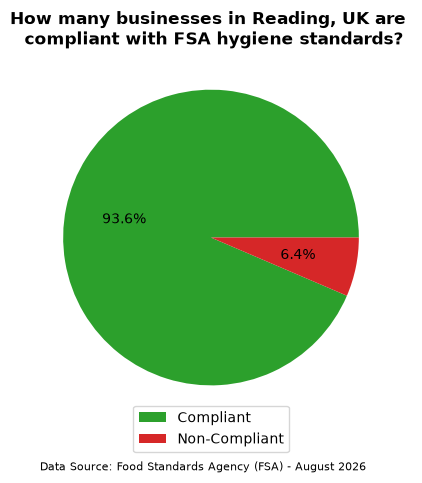

In [49]:
colours = ['#2ca02c', '#d62728']  # Green for Compliant, Red for Non-Compliant
plt.pie(compliance_counts, labels=None, autopct='%1.1f%%', colors=colours)
plt.title('How many businesses in Reading, UK are \n compliant with FSA hygiene standards?', fontweight='bold')
plt.legend(compliance_counts.index, loc='lower center', bbox_to_anchor=(0.5, -0.1))
plt.figtext(0.5, 0.01, 'Data Source: Food Standards Agency (FSA) - August 2026', ha='center', fontsize=8)
plt.show()
   

---
### 3. Break down non compliant ratings (Rating Breakdown)
This will show us how many food businesses have achieved a non-compliant score of 0-2 in Reading.
- Filter the dataset to just the non-compliant businesses in Reading.
- Calculate the number of businesses that have receieved each of the scores of 0, 1, and 2.
- Visualise our findings using the most appropriate chart.

**Filter the dataset to just the non-compliant businesses in Reading**

In [50]:
# Filter the dataset to just non-compliant busninesses
non_compliant_df = df[df['Compliance_Status'] == 'Non-Compliant']
display(non_compliant_df.head())

,LocalAuthorityBusinessID,BusinessName,BusinessType,RatingValue,RatingDate,AddressLine1,PostCode,LocalAuthorityName,PostCodeDistrict,Compliance_Status
8,137250,7 Seas Fresh Fish,Retailers - other,1,2025-02-13,88 Oxford Road,RG1 7LJ,Reading,RG1,Non-Compliant
25,06718,AK Superstore,Retailers - supermarkets/hypermarkets,2,2026-01-09,41 Tilehurst Road,RG1 7TT,Reading,RG1,Non-Compliant
32,06826,Allotment Productions,Retailers - other,1,2026-03-11,Unit 4a Paddock Road Industrial Estate Paddock...,RG4 5BY,Reading,RG4,Non-Compliant
34,1296,Al-Rehman General Store,Retailers - other,2,2026-02-02,45 Cholmeley Road,RG1 3NQ,Reading,RG1,Non-Compliant
39,144937,Amee's Kitchen,Other catering premises,1,2026-03-19,232 Shinfield Road,RG2 8EX,Reading,RG2,Non-Compliant


**Calculate the number of businesses that have receieved each of the scores of 0, 1, and 2**

In [51]:
rating_counts = non_compliant_df['RatingValue'].value_counts().sort_index()
display(rating_counts)

RatingValue
0     5
1    41
2    39
Name: count, dtype: int64

**Visualise**

For this information, I have chosen a bar chart to clearly show the specific distribution of the hygiene ratings of 0,1 and 2 across the non-compliant food businesses in Reading, making it easy to compare the number of each failing score at a glance.

It immediately shows that there are a very low number of businesses that have failed to meet the FSA standards scoring zero (5), and there is a similarity in the number of businesses that scored 1 and 2 (41 and 39 respectively). 

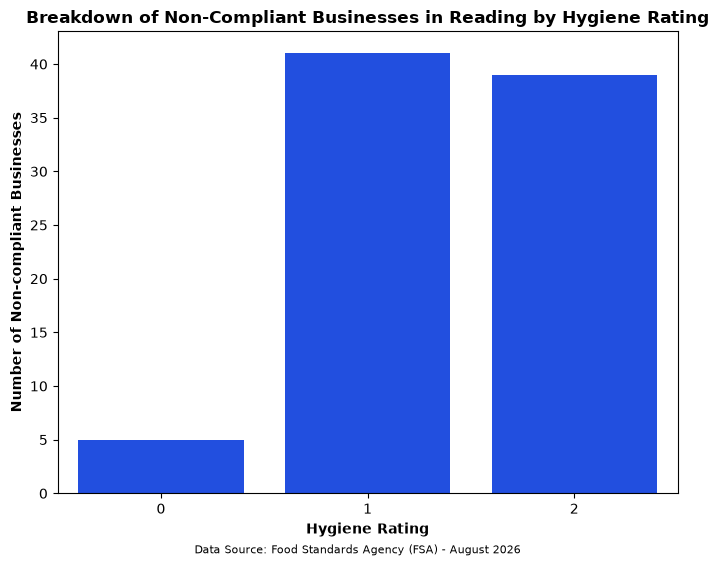

In [79]:
plt.figure(figsize=(8, 6))
sns.set_palette(palette='bright')
sns.barplot(x=rating_counts.index, y=rating_counts.values)
plt.title('Breakdown of Non-Compliant Businesses in Reading by Hygiene Rating', fontweight='bold')
plt.xlabel('Hygiene Rating', fontweight='bold')
plt.ylabel('Number of Non-compliant Businesses', fontweight='bold')
plt.figtext(0.5, 0.01, 'Data Source: Food Standards Agency (FSA) - August 2026', ha='center', fontsize=8)
plt.show()